In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.fft import fft, fftfreq
from scipy.signal import sawtooth

from utils.signals import *
from algs.kern_cd import KernCD
from algs.kernels import *

## toy examples

In [ ]:
fs = 100 # sampling frequency (Hz)
dt = 1 / fs
t = np.arange(0, 10, dt)
f = 0.5 # signal frequency (Hz)

x_true = np.sin(2*np.pi*f*t + 2.1)
#x_true = sawtooth(2*np.pi*f*t)
eps = .1 * np.random.randn(len(t))
x = x_true + eps

#window = np.hanning(len(x))
#x = x * window

est. freq.: 0.5


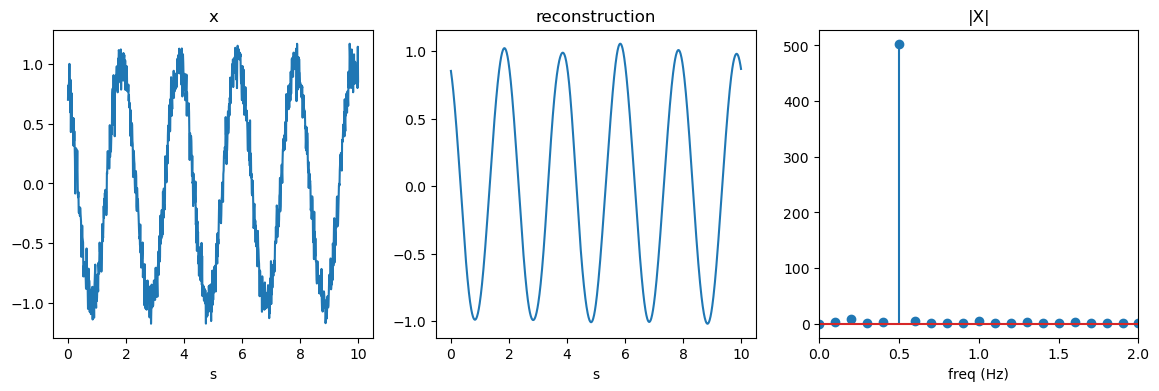

In [ ]:
analyze(x, fs=fs, max_f=2)

## robot data

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *
from sklearn.metrics.pairwise import rbf_kernel

In [5]:
npz = np.load('../data/humanoid/train.npz')
x = npz['states']
fail = npz['fail']

x.shape

(1000, 1000, 348)

In [6]:
x = StandardScaler().fit_transform(x.reshape(-1, x.shape[-1])).reshape(x.shape)

In [ ]:
fail[:100]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 487,   0,   0,
       638,   0,   0,   0,   0,   0, 725,   0,   0,   0,   0, 662, 411,
         0,   0,   0,   0,   0,   0,   0,   0,   0,  41,   0, 694,   0,
       551,   0,   0, 498,   0, 905,   0,   0, 437,   0,   0,   0,   0,
         0,   0, 808,   0, 372,   0,   0,   0,   0,   0,   0,   0,   0,
       791,   0,   0, 508,   0, 857,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0, 494,   0,   0, 849,   0,   0, 388,   0,   0, 527,
         0,   0, 855, 810,   0,   0, 523,   0,   0])

In [ ]:
int(np.ceil(2 / 0.062))

33

In [ ]:
fail[10]

487

est. freq.: 0.06


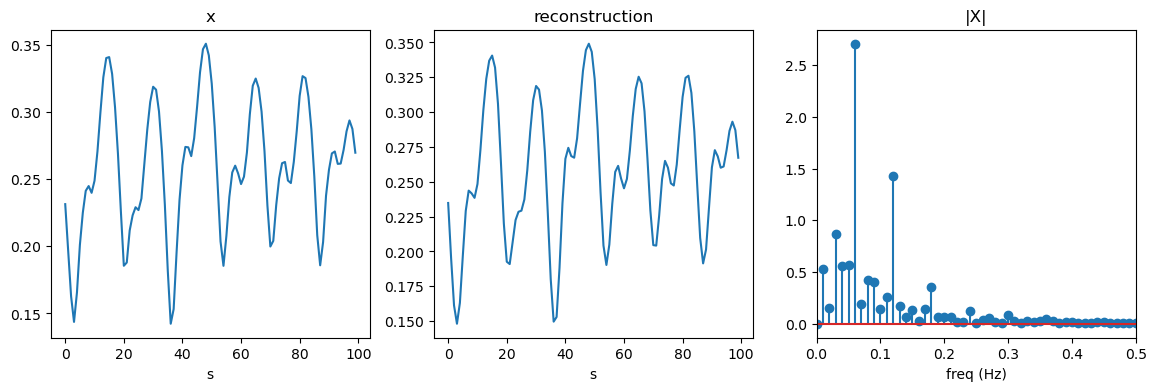

In [ ]:
i = 11
start = 0
win = 1000

analyze(x[i,start:start+win,0], max_f=0.5)

In [ ]:
X = np.abs(np.fft.rfft(x, axis=1))

<Axes: title={'center': 'failure'}>

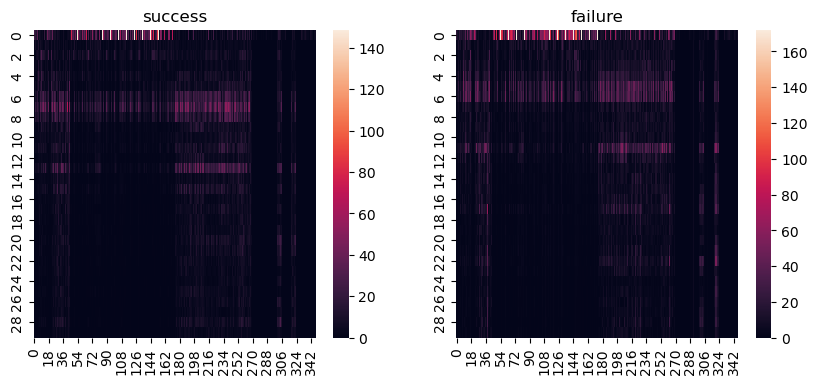

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].set_title('success')
sns.heatmap(X[43,:30], ax=ax[0])
ax[1].set_title('failure')
sns.heatmap(X[42,:30], ax=ax[1])

In [ ]:
fail[42]

498

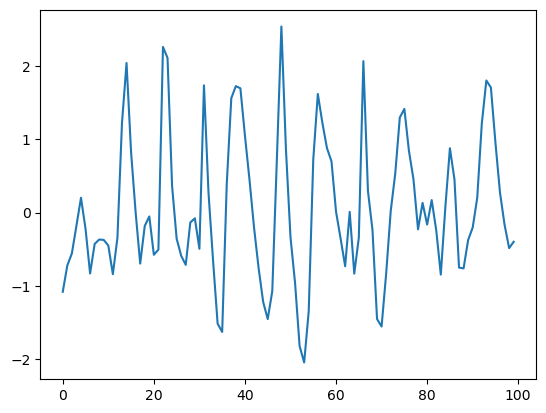

In [ ]:
plt.plot(x[23,370:470,235])

In [ ]:
np.where((fail > 450) & (fail < 550))

(array([ 10,  42,  68,  81,  90,  97, 146, 193, 209, 225, 230, 265, 328,
        369, 378, 553, 644, 647, 658, 679, 702, 790, 846, 869, 871, 878,
        880, 885, 948, 962]),)

In [ ]:
fail[42]

498

<StemContainer object of 3 artists>

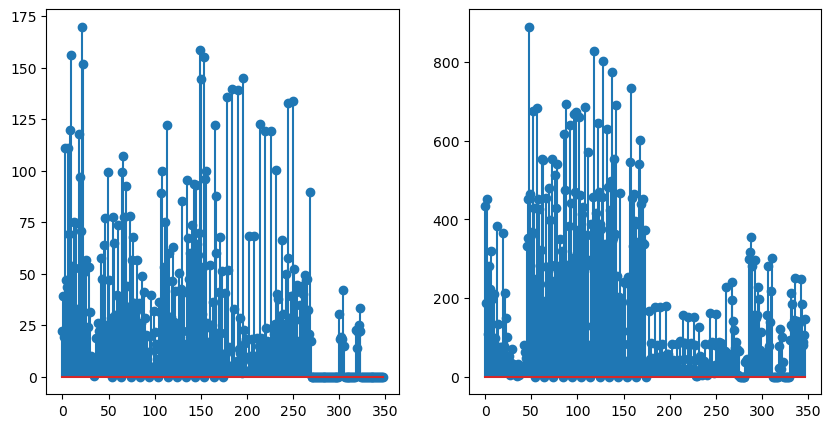

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].stem(X[0, 3])
ax[1].stem(X[10, 3])

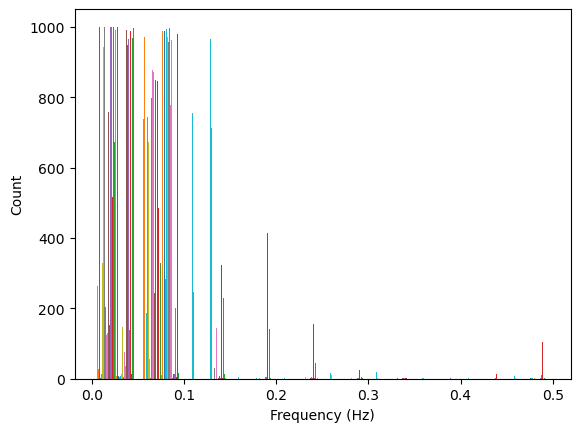

In [ ]:
peak_indices = np.argmax(np.abs(np.fft.rfft(x, axis=1)[:, 1:]), axis=1)
freq = np.fft.rfftfreq(x.shape[1])[1:][peak_indices]

# Plot histogram
plt.hist(freq)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Count')
plt.show()

In [8]:
ent = spectral_entropy(x, axis=1, trunc=None)
ent.shape

NameError: name 'spectral_entropy' is not defined

In [ ]:
K = rbf_kernel(ent, gamma=.15)
y = fail > 0

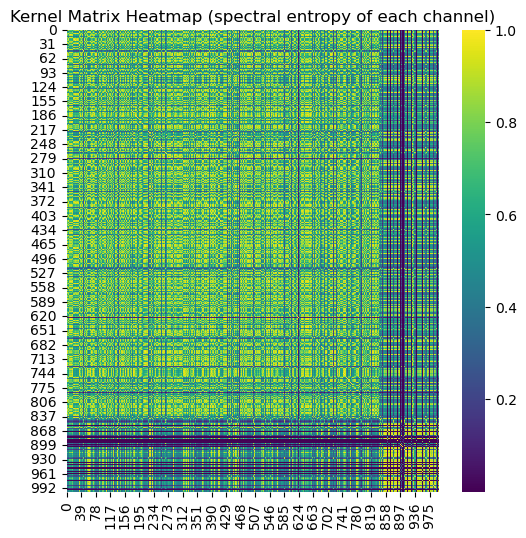

In [ ]:
idx = np.argsort(y)  # reorder by label
K_sorted = K[np.ix_(idx, idx)]

plt.figure(figsize=(6,6))
sns.heatmap(K_sorted, cmap='viridis')
plt.title("Kernel Matrix Heatmap (spectral entropy of each channel)")
plt.show()

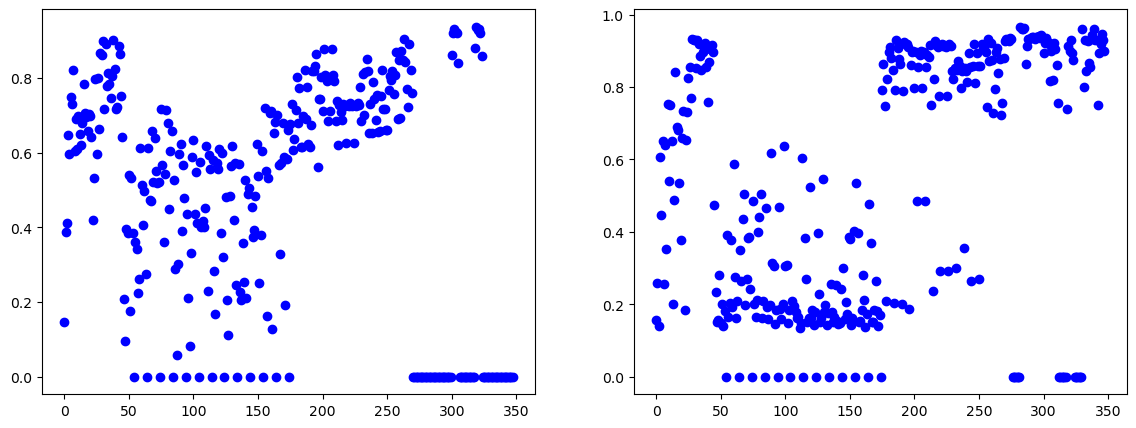

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(ent[0], 'bo')
ax[1].plot(ent[10], 'bo')

600 -- 672 -- 722 with 6 fails


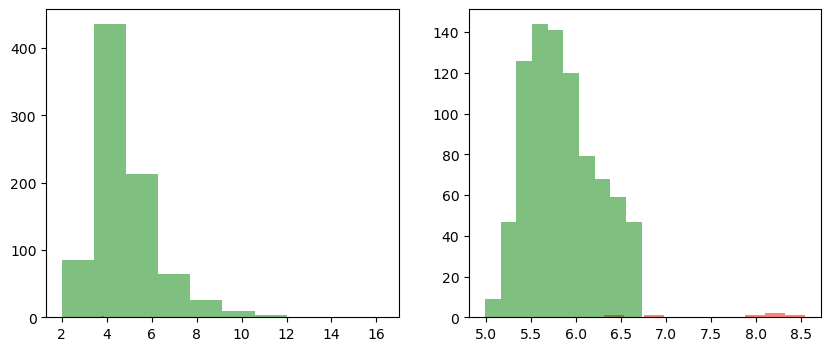

In [ ]:
idx = 0
deg = 5
n_dim = 10

start = 600
win = int(np.ceil(1 / 0.014))
end = start+win
hor = 50 # fail horizon

f_mask = (fail > end) & (fail < end+hor)
s_mask = fail == 0
print(f'{start} -- {end} -- {end+hor} with {np.sum(f_mask)} fails')

kern = PolyFFT(deg)

# compute kernel distances
k_f = kern(x[idx,start:end,:n_dim], x[f_mask,start:end,:n_dim])
k_s = kern(x[idx,start:end,:n_dim], x[s_mask,start:end,:n_dim])

# compute kern cd
lam = 1e-4
p = KernCD(kern, lam).fit(x[s_mask,start:end,:n_dim])
y_f = np.log(p.predict(x[f_mask,start:end,:n_dim]))
y_s = np.log(p.predict(x[s_mask,start:end,:n_dim]))

fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].hist(k_f, color='red', alpha=.5);
ax[0].hist(k_s, color='green', alpha=.5);

ax[1].hist(y_f, color='red', alpha=.5);
ax[1].hist(y_s, color='green', alpha=.5);

In [ ]:
def make_failure_windows(x: np.ndarray, fail: np.ndarray, win: int=150, hor: int=50, skip: int=50):
    X_list, y_list = [], []
    batch, time, _ = x.shape

    for i in range(batch):
        fail_step = fail[i]

        for start in range(0, time - win, skip):
            end = start + win            
            if end + hor > time: # Stop if we can’t look horizon steps ahead
                break
            # Check if failure occurs within next 'hor' steps
            # label = 1 if end <= fail_step < end + hor else 0
            label = 1 if fail_step < end + hor else 0
            X_list.append(x[i, start:end, :])
            y_list.append(label)

    X_windows = np.stack(X_list)
    y_labels = np.array(y_list, dtype=int)

    return X_windows, y_labels

In [ ]:
X_tr, y_tr = make_failure_windows(x[fail == 0], fail[fail == 0])
X_cal = X_tr[np.random.randint(low=0, high=len(X_tr), size=50)]
X_tr = X_tr[np.random.randint(low=0, high=len(X_tr), size=50)]

#kern = GaussFFT(gamma=0.5)
kern = PolyFFT(deg=5)
p = KernCD(kern, lam=1e-4).fit(X_tr)
thresh = np.quantile(np.log(p.predict(X_cal)), q=.99)

X, y = make_failure_windows(x[fail > 0], fail[fail > 0], skip=100, hor=100)

y_pred = np.log(p.predict(X)) > thresh

balanced_accuracy_score(y, y_pred)

KeyboardInterrupt: 

## FFT -> PCA

In [197]:
from experiments.safety_monitor import *
from sklearn.decomposition import PCA
from utils.plotting import plot_kern_mat

In [463]:
win = 60
hor = 20
task = SafetyMonitor('humanoid', Params(win=win, hor=hor))
x_tr, x_te = task.get_train_test()

starts = np.random.randint(100, x_tr.shape[1] - win + 1, size=len(x_tr))
idx = starts[:, None] + np.arange(win)[None, :]
x_tr = x_tr[np.arange(len(x_tr))[:, None], idx]
y_true = task.y_true

print(x_tr.shape)

Skipping traj 26 with fail 45: No valid window found.
Skipping traj 67 with fail 46: No valid window found.
Skipping traj 194 with fail 41: No valid window found.
Skipping traj 358 with fail 39: No valid window found.
Skipping traj 398 with fail 42: No valid window found.
Skipping traj 676 with fail 47: No valid window found.
Skipping traj 686 with fail 48: No valid window found.
Sampled windows from 993 / 1000 trajectories
(840, 60, 348)


In [ ]:
def get_feat(x, trunc=None):
    X =  np.abs(np.fft.fft(x, axis=1))
    if trunc is not None:
        X = X[:, :trunc]  # truncate Fourier coeffs
    #X /= X.sum(axis=1, keepdims=True)
    X /= X.sum(axis=1, keepdims=True) + 1e-6
    X = X.reshape(len(X), -1)
    #X = std.fit_transform(X)
    return X

features shape: 20880
num of pca comp: 210


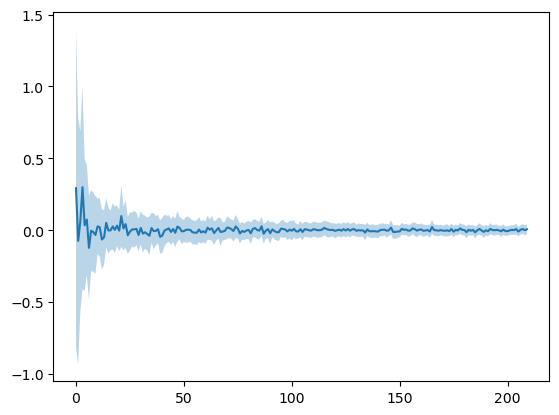

In [468]:
trunc = None

pca = PCA(n_components=0.95).fit(get_feat(x_tr, trunc=trunc))
z_te = pca.transform(get_feat(x_te, trunc=trunc))

print(f'features shape: {get_feat(x_tr, trunc=trunc).shape[1]}')
print(f'num of pca comp: {pca.n_components_}')

plt.plot(z_te.mean(axis=0))
plt.fill_between(range(z_te.shape[1]), 
                 z_te.mean(axis=0) - z_te.std(axis=0), 
                 z_te.mean(axis=0) + z_te.std(axis=0),
                 alpha=0.3);

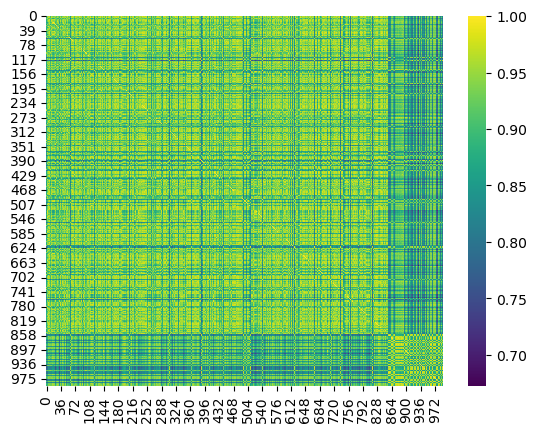

In [465]:
plot_kern_mat(rbf_kernel(z_te, gamma=.01), y_true, plt.gca())